In [ ]:
import numpy as np
muestra = np.random.binomial(1000000,0.4,size = 1000)

print(muestra)

[400464 400247 399611 399863 399822 399323 400214 399938 400639 400602
 399470 400107 399736 399867 399620 399818 400128 399903 400202 400338
 400426 400194 399158 399745 399657 400731 399951 400300 400176 399915
 399881 400327 399150 400744 399514 400166 400260 399466 400682 400872
 399113 400524 399537 399075 400042 399845 400037 400500 399959 399758
 399833 399626 400580 400066 401127 399691 400170 399572 401069 399899
 400601 400188 400194 399834 399761 400246 400178 399734 399577 399966
 399885 400586 399637 400788 399523 400295 399139 400345 400087 399376
 400075 399871 399770 400682 399275 399737 399981 399340 399305 400067
 399499 400222 400196 400402 400300 399233 399582 400794 399288 399698
 399959 399385 399760 400011 400241 399481 400052 399771 399883 399650
 399970 400247 399323 399934 400265 399878 400672 400551 399997 399812
 400295 399946 399489 400177 400400 399361 399577 400334 399482 400194
 399331 399138 399939 400364 399631 398906 399665 399411 399638 400351
 40056

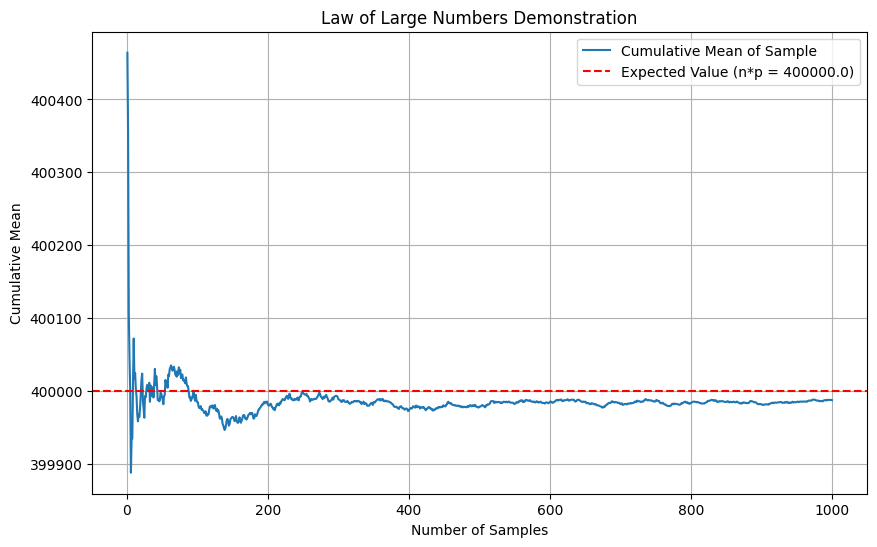

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the cumulative mean
cumulative_mean = np.cumsum(muestra) / np.arange(1, len(muestra) + 1)

# Theoretical expected value for Binomial(n=5, p=0.4)
expected_value = 1000000 * 0.4

# Plotting the Law of Large Numbers
plt.figure(figsize=(10, 6))
sns.lineplot(x=np.arange(1, len(muestra) + 1), y=cumulative_mean, label='Cumulative Mean of Sample')
plt.axhline(y=expected_value, color='r', linestyle='--', label=f'Expected Value (n*p = {expected_value})')

plt.xlabel('Number of Samples')
plt.ylabel('Cumulative Mean')
plt.title('Law of Large Numbers Demonstration')
plt.legend()
plt.grid(True)
plt.show()

### Teorema del Límite Central (Central Limit Theorem)

El Teorema del Límite Central (TLC) establece que, dadas suficientes muestras independientes e idénticamente distribuidas de una población con una media y una varianza finitas, la distribución de la media muestral se aproximará a una distribución normal, independientemente de la forma de la distribución de la población original. Esto es válido incluso si la población original no es normal.

Aquí, tomaremos múltiples muestras de su distribución binomial, calcularemos la media de cada muestra y luego graficaremos un histograma de estas medias. Verá que este histograma se asemejará a una curva de campana (distribución normal).

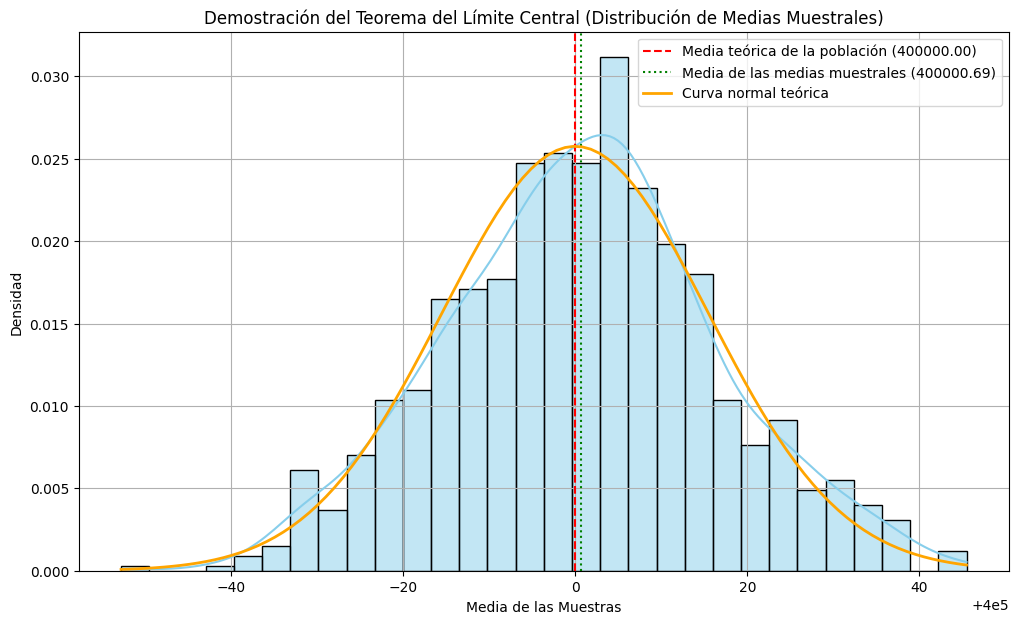

In [ ]:
# Parámetros de la distribución binomial original
n_trials_original = 1000000
p_success_original = 0.4

# Número de muestras a generar
num_samples = 1000

# Tamaño de cada sub-muestra (por ejemplo, 1000, para que el teorema se aplique bien)
sample_size = 1000

# Generar múltiples muestras de la distribución binomial y calcular sus medias
sample_means = []
for _ in range(num_samples):
    # Generamos una muestra de la distribución binomial
    # El `n` en binomial(n, p, size) es el número de "ensayos" en cada experimento.
    # El `size` es el número de experimentos realizados.
    # Aquí, queremos que cada "sub-muestra" de tamaño `sample_size` consista en extracciones
    # de la distribución binomial original, donde cada extracción es un solo resultado
    # de `n_trials_original` ensayos binomiales.
    # Sin embargo, dado que `muestra` ya contiene los resultados de 1000 experimentos
    # de Binomial(1000000, 0.4), podemos tomar sub-muestras de `muestra` para el TLC.

    # Tomar una sub-muestra aleatoria de la 'muestra' generada previamente
    # o generar nuevas muestras del mismo tipo si es que el `size` de `muestra` no es suficiente.
    # Para este ejercicio, vamos a generar nuevas muestras para que el 'sample_size' funcione como
    # el número de elementos en cada 'media' que calculamos.

    # Generar `sample_size` realizaciones de la binomial original para cada 'experimento'
    sub_sample = np.random.binomial(n_trials_original, p_success_original, size=sample_size)
    sample_means.append(np.mean(sub_sample))

# Convertir la lista a un array numpy para facilitar el cálculo
sample_means = np.array(sample_means)

# Calcular la media y la desviación estándar de las medias muestrales
mean_of_sample_means = np.mean(sample_means)
std_dev_of_sample_means = np.std(sample_means)

# Media teórica de la población (ya calculada como expected_value)
# expected_value = n_trials_original * p_success_original

# Desviación estándar teórica de la población
std_dev_population = np.sqrt(n_trials_original * p_success_original * (1 - p_success_original))

# Error estándar de la media (std_dev_population / sqrt(sample_size))
standard_error_mean = std_dev_population / np.sqrt(sample_size)

# Plotear el histograma de las medias muestrales
plt.figure(figsize=(12, 7))
sns.histplot(sample_means, bins=30, kde=True, stat='density', color='skyblue', edgecolor='black')

# Trazar la media teórica de la población
plt.axvline(expected_value, color='red', linestyle='--', label=f'Media teórica de la población ({expected_value:.2f})')

# Trazar la media de las medias muestrales
plt.axvline(mean_of_sample_means, color='green', linestyle=':', label=f'Media de las medias muestrales ({mean_of_sample_means:.2f})')

# Añadir una curva de distribución normal teórica
x = np.linspace(min(sample_means), max(sample_means), 100)
from scipy.stats import norm
plt.plot(x, norm.pdf(x, loc=expected_value, scale=standard_error_mean), color='orange', linestyle='-', linewidth=2, label='Curva normal teórica')

plt.title('Demostración del Teorema del Límite Central (Distribución de Medias Muestrales)')
plt.xlabel('Media de las Muestras')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()